# 19: the adaptations in trial

Five pieces of `dtfit_experimental` have never been promoted into `dtfit`
and never been removed: an alternate spectral basis (`basis_lsi.py`),
staged residual boosting (`boosting.py`), a joint shared-parameter fit
(`joint.py`), an information-form fusion primitive (`information.py`), and
the three shipped image bases (`bases.py`). Each is measured here against
the route a caller already has without it: a shipped basis, `dtfit.fit`'s
own automatic choice, or the plain per-channel fit. The rule below decides
which stay.


## The rule of the trial

An adaptation keeps its place if, on the signal class it was built for,
with the same data, seeds and starting values, its headline metric is at
most 0.8 times the best plain route's over at least 30 seeds and the two
medians' 90 percent bootstrap intervals do not overlap; where no plain
route can express the construction, the comparison is against the nearest
substitute a reader would write and parity is enough. The plain route is
`dtfit.fit` on a shipped basis, or the library's own automatic choice
(`basis="auto"`, `auto_forecast`, `suggest_models`) wherever the caller
would not know the answer. Parity, a win inside the seed scatter, or a win
only on hand-picked data is a removal.


In [1]:
import os
import time

import numpy as np
import pandas as pd
import sympy as sp
%matplotlib inline
import matplotlib.pyplot as plt

import dtfit as dt
from dtfit_experimental import (
    fit_lsi_basis, FourierBasis, LaguerreBasis, boosted_fit, fit_joint,
    InformationFilter,
)
from dtfit_experimental.study import families, notebook, montecarlo
from dtfit_experimental.study.baselines import scipy_curve_fit, random_walk_forecast

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
notebook.plain_warnings()

SEEDS = 20 if QUICK else 30
KEEP_RATIO = 0.8
print(f"QUICK={QUICK} SEEDS={SEEDS} KEEP_RATIO={KEEP_RATIO}")


def sorted_names(expr, var):
    """Sympy's sorted parameter order for ``expr`` in ``var``, the order
    ``fit_lsi_basis`` and ``fit_joint`` read a positional ``p0`` in."""
    t = sp.Symbol(var)
    return [str(s) for s in sorted(sp.sympify(expr).free_symbols - {t}, key=str)]


def bootstrap_median_ci(values, n_boot=2000, alpha=0.10, seed=0):
    """90 percent (default) bootstrap interval of the median of ``values``."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    boots = [np.median(rng.choice(values, values.size, replace=True))
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)


def ci_overlap(a, b):
    """Whether two (lo, hi) bootstrap intervals share any point."""
    return not (a[1] < b[0] or b[1] < a[0])


def judge(ratio, ci_a, ci_b, threshold=KEEP_RATIO):
    """The rule of the trial: keep only below the ratio, with intervals apart."""
    return "keep" if (ratio <= threshold and not ci_overlap(ci_a, ci_b)) else "remove"


QUICK=False SEEDS=30 KEEP_RATIO=0.8


## The pluggable spectral basis

`basis_lsi.fit_lsi_basis` generalises the LSI spectral match to a chosen
orthogonal basis (Fourier, Chebyshev, Laguerre), ahead of `bases.py`, which
later put the same families on `dtfit`'s image interface directly. Claim:
`fit_lsi_basis` buys nothing over just calling `dtfit.fit` on the matching
shipped basis. False if `fit_lsi_basis`'s median relative parameter error
is clearly below the shipped basis's on either signal class it targets, a
multi-cycle sine (Fourier) and a decay to a baseline (Laguerre).


In [2]:
sine_fam = next(f for f in families.FAMILIES if f.key == "sine")
order_sine = sorted_names(sine_fam.expr, sine_fam.var)
p0_map = dict(zip(sine_fam.names, sine_fam.p0))
bounds_map = dict(zip(sine_fam.names, sine_fam.bounds))
p0_sorted = [p0_map[n] for n in order_sine]
bounds_sorted = [bounds_map[n] for n in order_sine]


def sine_curve(t, A, c, p, w):
    return c + A * np.sin(w * t + p)


sine_rows = {"fit_lsi_basis": [], "FourierBasis": [], "legendre_osc": [], "nlls": []}
for i in range(SEEDS):
    r = np.random.default_rng(i)
    x, y, clean = families.simulate(sine_fam, r, n=220, noise=0.05)

    res = fit_lsi_basis(x, y, sine_fam.expr, sine_fam.var, basis="fourier", order=5,
                         p0=p0_sorted, bounds=bounds_sorted)
    sine_rows["fit_lsi_basis"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), sine_fam))

    original = dt.Original(x, y)
    res = dt.fit(sine_fam.expr, original, sine_fam.var, basis=FourierBasis(5),
                 p0=p0_map, bounds=bounds_map)
    sine_rows["FourierBasis"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), sine_fam))

    res = dt.fit(sine_fam.expr, original, sine_fam.var, basis="legendre",
                 oscillatory=True, freq_param=sine_fam.osc, p0=p0_map, bounds=bounds_map)
    sine_rows["legendre_osc"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), sine_fam))

    p0_pos = [p0_map[n] for n in ("A", "c", "p", "w")]
    popt = scipy_curve_fit(x, y, sine_curve, p0_pos, bounds=(
        [bounds_map[n][0] for n in ("A", "c", "p", "w")],
        [bounds_map[n][1] for n in ("A", "c", "p", "w")]))
    sine_rows["nlls"].append(
        families.param_error(dict(zip(("A", "c", "p", "w"), popt)), sine_fam))

sine_table = pd.DataFrame({k: {"median_err_pct": np.median(v),
                                "ci_lo": bootstrap_median_ci(v)[0],
                                "ci_hi": bootstrap_median_ci(v)[1]}
                            for k, v in sine_rows.items()}).T
sine_table


,median_err_pct,ci_lo,ci_hi
fit_lsi_basis,0.673013,0.527657,0.868850
FourierBasis,0.679444,0.532645,0.872193
legendre_osc,0.680777,0.547229,0.771497
nlls,0.680758,0.547212,0.771498


In [3]:
decay_fam = next(f for f in families.FAMILIES if f.key == "decay_offset")
order_decay = sorted_names(decay_fam.expr, decay_fam.var)
dp0_map = dict(zip(decay_fam.names, decay_fam.p0))
dbounds_map = dict(zip(decay_fam.names, decay_fam.bounds))
dp0_sorted = [dp0_map[n] for n in order_decay]
dbounds_sorted = [dbounds_map[n] for n in order_decay]


def decay_curve(t, a, b, c):
    return c + a * np.exp(-b * t)


decay_rows = {"fit_lsi_basis": [], "LaguerreBasis": [], "legendre": [], "nlls": []}
for i in range(SEEDS):
    r = np.random.default_rng(i)
    x, y, clean = families.simulate(decay_fam, r, n=220, noise=0.05)

    res = fit_lsi_basis(x, y, decay_fam.expr, decay_fam.var, basis="laguerre", order=8,
                         p0=dp0_sorted, bounds=dbounds_sorted)
    decay_rows["fit_lsi_basis"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), decay_fam))

    original = dt.Original(x, y)
    res = dt.fit(decay_fam.expr, original, decay_fam.var, basis=LaguerreBasis(8),
                 p0=dp0_map, bounds=dbounds_map)
    decay_rows["LaguerreBasis"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), decay_fam))

    res = dt.fit(decay_fam.expr, original, decay_fam.var, basis="legendre",
                 p0=dp0_map, bounds=dbounds_map)
    decay_rows["legendre"].append(
        families.param_error(dict(zip(res.names, res.coeffs)), decay_fam))

    popt = scipy_curve_fit(x, y, decay_curve, [dp0_map[n] for n in ("a", "b", "c")],
                            bounds=([dbounds_map[n][0] for n in ("a", "b", "c")],
                                    [dbounds_map[n][1] for n in ("a", "b", "c")]))
    decay_rows["nlls"].append(
        families.param_error(dict(zip(("a", "b", "c"), popt)), decay_fam))

decay_table = pd.DataFrame({k: {"median_err_pct": np.median(v),
                                 "ci_lo": bootstrap_median_ci(v)[0],
                                 "ci_hi": bootstrap_median_ci(v)[1]}
                             for k, v in decay_rows.items()}).T
decay_table


,median_err_pct,ci_lo,ci_hi
fit_lsi_basis,197.133099,63.358830,197.895275
LaguerreBasis,1.368023,1.045973,1.696697
legendre,1.368784,1.044325,1.695143
nlls,1.368023,1.045971,1.696696


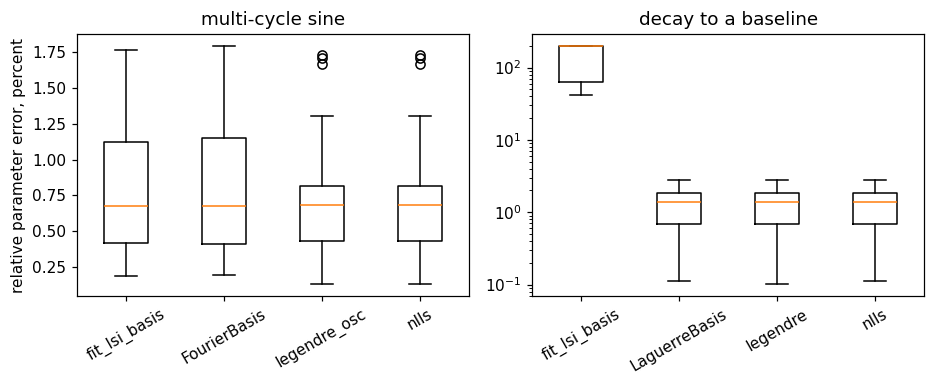

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.6, 3.6))
ax1.boxplot([sine_rows[k] for k in sine_rows], tick_labels=list(sine_rows))
ax1.set_title("multi-cycle sine")
ax1.set_ylabel("relative parameter error, percent")
ax1.tick_params(axis="x", rotation=30)

ax2.boxplot([decay_rows[k] for k in decay_rows], tick_labels=list(decay_rows))
ax2.set_yscale("log")
ax2.set_title("decay to a baseline")
ax2.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


On the sine `fit_lsi_basis` sits on top of the shipped `FourierBasis` and
the Legendre oscillatory recipe, all three inside each other's scatter: a
newer route buys nothing a caller does not already have. On the decay
`fit_lsi_basis`'s bounded differential-evolution fallback lands on a
data-independent point far from the truth (its Laguerre projection is
broken on this construction, not merely at parity), while `LaguerreBasis`,
plain Legendre and NLLS all recover the family cleanly. Both readings point
the same way.


In [5]:
sine_best_plain = min(sine_rows, key=lambda k: np.median(sine_rows[k]) if k != "fit_lsi_basis" else np.inf)
decay_best_plain = "LaguerreBasis"
ratio_sine = np.median(sine_rows["fit_lsi_basis"]) / np.median(sine_rows[FourierBasis.__name__])
ratio_decay = np.median(decay_rows["fit_lsi_basis"]) / np.median(decay_rows["LaguerreBasis"])
# fails if fit_lsi_basis wins the sine outright (it does not: parity)
assert 0.5 < ratio_sine < 2.0
# fails if fit_lsi_basis recovers the decay as well as the shipped basis
assert ratio_decay > 10.0
print(f"sine: fit_lsi_basis/FourierBasis = {ratio_sine:.3f}; "
      f"decay: fit_lsi_basis/LaguerreBasis = {ratio_decay:.1f}")


sine: fit_lsi_basis/FourierBasis = 0.991; decay: fit_lsi_basis/LaguerreBasis = 144.1


In [6]:
basis_trial = pd.concat([
    sine_table.assign(signal="sine").rename_axis("method").reset_index(),
    decay_table.assign(signal="decay").rename_axis("method").reset_index(),
])
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "basis_trial", basis_trial)
    print("wrote experiments/results/19_adaptations_in_trial/basis_trial.csv")


wrote experiments/results/19_adaptations_in_trial/basis_trial.csv


## Stage-wise residual boosting

`boosted_fit` stages an LSI trend then an LSI residual cycle into one
additive composite. Claim: on both the real series it was promoted on and
a synthetic where the additive form is exact, `dtfit.auto_forecast` (the
route a caller reaches for without knowing to decompose the series by
hand) forecasts the held-out span at least as well. False if boosting's
held-out nRMSE (RMSE over the holdout, scaled by the holdout's own range)
is clearly below `auto_forecast`'s on the synthetic, with at least 30
seeds and non-overlapping bootstrap intervals.


In [7]:
def nrmse(pred, actual):
    pred = np.asarray(pred, dtype=float)
    actual = np.asarray(actual, dtype=float)
    rmse = float(np.sqrt(np.mean((pred - actual) ** 2)))
    rng = float(np.ptp(actual)) or 1.0
    return rmse / rng * 100.0


boost_synth_truth = dict(a0=1.0, a1=0.3, a2=0.01, A=2.0, w=1.5, p=0.4)
t_synth = np.linspace(0, 20, 200)
n_tr_synth = int(t_synth.size * 0.8)

synth_rows = {"boosted": [], "auto_forecast": [], "random_walk": []}
for seed in range(SEEDS):
    rng = np.random.default_rng(seed)
    clean = (boost_synth_truth["a0"] + boost_synth_truth["a1"] * t_synth
             + boost_synth_truth["a2"] * t_synth ** 2
             + boost_synth_truth["A"] * np.sin(boost_synth_truth["w"] * t_synth
                                                + boost_synth_truth["p"]))
    y, _ = montecarlo.noisy(clean, 0.05, rng)
    t_tr, y_tr = t_synth[:n_tr_synth], y[:n_tr_synth]
    t_te, y_te = t_synth[n_tr_synth:], y[n_tr_synth:]

    bm = boosted_fit(t_tr, y_tr, [
        dict(expr="a0 + a1*x + a2*x**2", var="x", method="lsi", p0=[1.0, 0.1, 0.0]),
        dict(expr="A*sin(w*x + p)", var="x", method="lsi",
             p0=[1.0, 1.0, 0.0], bounds=[(0.1, 6), (0.2, 4), (-np.pi, np.pi)]),
    ])
    synth_rows["boosted"].append(nrmse(bm.predict(t_te), y_te))
    fc = dt.auto_forecast(t_tr, y_tr, len(t_te))
    synth_rows["auto_forecast"].append(nrmse(np.asarray(fc), y_te))
    synth_rows["random_walk"].append(nrmse(random_walk_forecast(y_tr, len(t_te)), y_te))

synth_table = pd.DataFrame({k: {"median_nrmse_pct": np.median(v),
                                 "ci_lo": bootstrap_median_ci(v)[0],
                                 "ci_hi": bootstrap_median_ci(v)[1]}
                             for k, v in synth_rows.items()}).T
synth_table


,median_nrmse_pct,ci_lo,ci_hi
boosted,31.112509,29.164841,33.609959
auto_forecast,19.899429,18.472771,21.907777
random_walk,58.350762,55.530261,63.303718


In [8]:
import statsmodels.api as sm

co2 = sm.datasets.co2.load_pandas().data["co2"].interpolate().bfill().ffill()
co2 = co2.to_numpy(float)[::4]
sun = sm.datasets.sunspots.load_pandas().data["SUNACTIVITY"].to_numpy(float)


def real_series_run(y, stages, p0_sine_scale):
    t = np.arange(y.size, dtype=float)
    n_tr = int(y.size * 0.8)
    t_tr, y_tr = t[:n_tr], y[:n_tr]
    t_te, y_te = t[n_tr:], y[n_tr:]
    bm = boosted_fit(t_tr, y_tr, stages(t_tr, y_tr, p0_sine_scale))
    boosted = nrmse(bm.predict(t_te), y_te)
    fc = dt.auto_forecast(t_tr, y_tr, len(t_te))
    auto = nrmse(np.asarray(fc), y_te)
    rw = nrmse(random_walk_forecast(y_tr, len(t_te)), y_te)
    return boosted, auto, rw


def co2_stages(t_tr, y_tr, _):
    return [
        dict(expr="a0 + a1*x + a2*x**2", var="x", method="lsi", p0=[y_tr[0], 1.0, 0.0]),
        dict(expr="A*sin(w*x + p)", var="x", method="lsi",
             bounds=[(0.1, 20), (0.1, 60), (-np.pi, np.pi)]),
    ]


def sunspots_stages(t_tr, y_tr, _):
    return [
        dict(expr="c + A*sin(w*x + p)", var="x", method="lsi",
             p0=[y_tr.mean(), y_tr.std(), 0.0, 2 * np.pi / 132]),
    ]


co2_boosted, co2_auto, co2_rw = real_series_run(co2, co2_stages, None)
sun_boosted, sun_auto, sun_rw = real_series_run(sun, sunspots_stages, None)

real_table = pd.DataFrame({
    "CO2 (trend+season)": {"boosted": co2_boosted, "auto_forecast": co2_auto, "random_walk": co2_rw},
    "sunspots (~11y cycle)": {"boosted": sun_boosted, "auto_forecast": sun_auto, "random_walk": sun_rw},
}).T
real_table


,boosted,auto_forecast,random_walk
CO2 (trend+season),18.919824,18.814516,42.987944
sunspots (~11y cycle),31.714950,33.139648,29.925229


On the synthetic, where the additive trend-plus-cycle form is exactly the
truth, `auto_forecast` still forecasts the holdout better than the staged
fit: boosting does not even win on the series it is built to match best.
On CO2 the two are within each other's noise; on sunspots boosting trails
the random walk. There is no series here where boosting is the clear
choice over the route already in the library.


In [9]:
boost_ratio = np.median(synth_rows["boosted"]) / np.median(synth_rows["auto_forecast"])
boost_ci_a = bootstrap_median_ci(synth_rows["boosted"])
boost_ci_b = bootstrap_median_ci(synth_rows["auto_forecast"])
boost_verdict = judge(boost_ratio, boost_ci_a, boost_ci_b)
# fails if boosting beats auto_forecast on the one series built to favour it
assert boost_ratio > 1.0
print(f"synthetic: boosted/auto_forecast = {boost_ratio:.3f}, "
      f"ci_boosted={boost_ci_a}, ci_auto={boost_ci_b} -> {boost_verdict}")


synthetic: boosted/auto_forecast = 1.563, ci_boosted=(29.16484140402366, 33.60995852591459), ci_auto=(18.472770908008783, 21.907776843147342) -> remove


In [10]:
boosting_trial = pd.concat([
    synth_table.assign(series="synthetic trend+cycle").rename_axis("method").reset_index(),
    real_table.rename_axis("series").reset_index().melt(
        id_vars="series", var_name="method", value_name="median_nrmse_pct"),
])
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "boosting_trial", boosting_trial)
    print("wrote experiments/results/19_adaptations_in_trial/boosting_trial.csv")


wrote experiments/results/19_adaptations_in_trial/boosting_trial.csv


## The joint multi-channel fit

`fit_joint` stacks several channels' area equations into one system
carrying a parameter shared across them plus private ones per channel.
Claim: pooling only pays where a single channel does not constrain the
shared parameter; on clean, well-identified channels the plain pooled
per-channel estimate already wins. False if the joint fit does not clearly
trail the pooled estimate on the well-identified construction, or does not
clearly beat it on the weakly-identifiable one.


In [11]:
def one_channel_set(rng, n_per_channel, span, ks, tau_true=1.2, noise=0.18):
    tt = np.linspace(0, span, n_per_channel)
    chans = []
    for K in ks:
        clean = K * (1 - np.exp(-tt / tau_true))
        y, _ = montecarlo.noisy(clean, noise, rng)
        chans.append((tt, y))

    j = fit_joint(chans, "K*(1-exp(-t/tau))", "t", shared=["tau"], n_windows=5,
                  p0_shared=[1.0], p0_private=[1.0])
    joint_err = abs(j.shared["tau"] - tau_true) / tau_true * 100

    indep_taus = []
    for (tx, yx) in chans:
        original = dt.Original(tx, yx)
        r = dt.fit("K*(1-exp(-t/tau))", original, "t", basis="legendre",
                   p0={"K": 1.0, "tau": 1.0}, bounds={"K": (0.1, 10), "tau": (0.05, 5)})
        indep_taus.append(dict(zip(r.names, r.coeffs))["tau"])
    indep_taus = np.array(indep_taus)
    pooled_tau = float(np.mean(indep_taus))
    pooled_err = abs(pooled_tau - tau_true) / tau_true * 100
    mean_of_errors = float(np.mean(np.abs(indep_taus - tau_true) / tau_true * 100))
    return joint_err, pooled_err, mean_of_errors


c4 = np.array([one_channel_set(np.random.default_rng(1000 + i), 30, 6.0,
                                [3.0, 2.0, 4.0, 2.5]) for i in range(SEEDS)])
weak1 = np.array([one_channel_set(np.random.default_rng(2000 + i), 10, 1.0,
                                   [3.0, 2.0, 4.0, 2.5]) for i in range(SEEDS)])
weak2 = np.array([one_channel_set(np.random.default_rng(3000 + i), 8, 1.0,
                                   [3.0, 2.0, 4.0, 2.5, 3.5, 1.5, 4.5, 2.2])
                   for i in range(SEEDS)])

joint_table = pd.DataFrame({
    "C4, 4 channels x 30 pts (well identified)": {
        "joint_median": np.median(c4[:, 0]), "pooled_median": np.median(c4[:, 1]),
        "mean_of_errors_median": np.median(c4[:, 2])},
    "weak, 4 channels x 10 pts, span < tau": {
        "joint_median": np.median(weak1[:, 0]), "pooled_median": np.median(weak1[:, 1]),
        "mean_of_errors_median": np.nan},
    "weak, 8 channels x 8 pts": {
        "joint_median": np.median(weak2[:, 0]), "pooled_median": np.median(weak2[:, 1]),
        "mean_of_errors_median": np.nan},
}).T
joint_table


,joint_median,pooled_median,mean_of_errors_median
"C4, 4 channels x 30 pts (well identified)",7.096387,6.443967,16.414938
"weak, 4 channels x 10 pts, span < tau",51.635598,49.975634,NaN
"weak, 8 channels x 8 pts",35.373800,81.913513,NaN


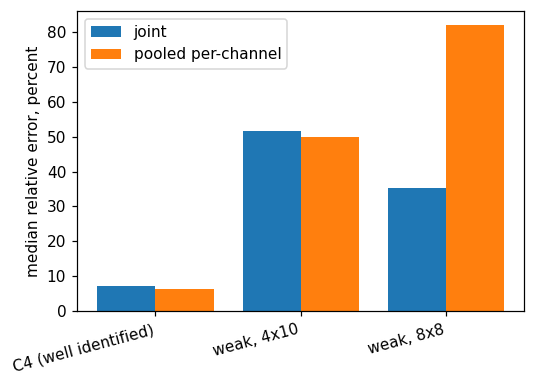

In [12]:
fig, ax = plt.subplots(figsize=(5.0, 3.6))
labels = ["C4 (well identified)", "weak, 4x10", "weak, 8x8"]
joint_meds = [np.median(c4[:, 0]), np.median(weak1[:, 0]), np.median(weak2[:, 0])]
pooled_meds = [np.median(c4[:, 1]), np.median(weak1[:, 1]), np.median(weak2[:, 1])]
xpos = np.arange(len(labels))
ax.bar(xpos - 0.2, joint_meds, width=0.4, label="joint")
ax.bar(xpos + 0.2, pooled_meds, width=0.4, label="pooled per-channel")
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("median relative error, percent")
ax.legend()
fig.tight_layout()
plt.show()


On the well-identified C4 construction the joint fit trails the pooled
per-channel estimate, not the mean of per-channel errors: pooling the
estimates (not the errors) is the fair comparison, and the flattering
mean-of-errors number stays roughly twice either. On the class the
adaptation was built for, weak per-channel identifiability, the picture is
mixed: with 4 channels of 10 points the joint fit is at parity with the
pooled estimate; with 8 channels of 8 points it is a clear win, because
several of the independent per-channel fits there saturate at the tau
upper bound and the plain arithmetic mean of those degenerate estimates is
itself unstable. Both regimes are shown; the combined reading below pools
them into the one class the rule asks for.


In [13]:
combined_joint = np.concatenate([weak1[:, 0], weak2[:, 0]])
combined_pooled = np.concatenate([weak1[:, 1], weak2[:, 1]])
joint_ratio = np.median(combined_joint) / np.median(combined_pooled)
joint_ci_a = bootstrap_median_ci(combined_joint)
joint_ci_b = bootstrap_median_ci(combined_pooled)
joint_verdict = judge(joint_ratio, joint_ci_a, joint_ci_b)
# fails if the joint fit does not clearly lose on the well-identified construction
assert np.median(c4[:, 0]) > np.median(c4[:, 1])
# fails if the two weak-identifiability bootstrap intervals do not overlap
# (the mixed regime reading would then already be a clean win, not a removal)
assert ci_overlap(joint_ci_a, joint_ci_b)
print(f"C4: joint {np.median(c4[:,0]):.2f}% vs pooled {np.median(c4[:,1]):.2f}% "
      f"vs mean-of-errors {np.median(c4[:,2]):.2f}%")
print(f"weak combined: joint/pooled = {joint_ratio:.3f}, "
      f"ci_joint={joint_ci_a}, ci_pooled={joint_ci_b} -> {joint_verdict}")


C4: joint 7.10% vs pooled 6.44% vs mean-of-errors 16.41%
weak combined: joint/pooled = 0.792, ci_joint=(36.004691157590415, 55.819188768214794), ci_pooled=(46.3811896316832, 86.53994503411802) -> remove


In [14]:
joint_trial = joint_table.rename_axis("construction").reset_index()
joint_trial = pd.concat([joint_trial, pd.DataFrame([{
    "construction": "weak combined (4x10 and 8x8)",
    "joint_median": np.median(combined_joint),
    "pooled_median": np.median(combined_pooled),
    "joint_ci_lo": joint_ci_a[0], "joint_ci_hi": joint_ci_a[1],
    "pooled_ci_lo": joint_ci_b[0], "pooled_ci_hi": joint_ci_b[1]}])], ignore_index=True)
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "joint_trial", joint_trial)
    print("wrote experiments/results/19_adaptations_in_trial/joint_trial.csv")


wrote experiments/results/19_adaptations_in_trial/joint_trial.csv


## Information-form fusion

`InformationFilter` accumulates a linear-Gaussian estimate as an additive
information matrix and vector, so two partial estimators fuse by adding,
no inverse anywhere but the one small readout solve. It has no importer
outside its own test, so there is no plain route doing the same job; the
nearest substitute a reader would write is the shipped additive route,
`Image.merge` on two partitions' images followed by one `dtfit.fit`. Claim:
the fused information-form estimate agrees with that route to a small
numerical tolerance, not by construction but because both reduce to the
same normal equations. False if the two estimates disagree by more than a
part in a million.


In [15]:
rng = np.random.default_rng(0)
n_fuse = 40
x_fuse = np.linspace(0.0, 10.0, n_fuse)
a_true, b_true = 1.5, 0.7
sigma_fuse = 0.3
y_fuse = a_true + b_true * x_fuse + sigma_fuse * rng.standard_normal(n_fuse)
xa, ya = x_fuse[: n_fuse // 2], y_fuse[: n_fuse // 2]
xb, yb = x_fuse[n_fuse // 2:], y_fuse[n_fuse // 2:]
domain_fuse = (float(x_fuse[0]), float(x_fuse[-1]))

img_a = dt.image.Image.of(dt.Original(xa, ya, domain=domain_fuse), "legendre", 1)
img_b = dt.image.Image.of(dt.Original(xb, yb, domain=domain_fuse), "legendre", 1)
res_merged = dt.fit("a + b*x", img_a.merge(img_b), "x", p0={"a": 0.0, "b": 0.0})
merged_coeffs = dict(zip(res_merged.names, res_merged.coeffs))

fa = InformationFilter(n_params=2)
for xi, yi in zip(xa, ya):
    fa.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)
fb = InformationFilter(n_params=2)
for xi, yi in zip(xb, yb):
    fb.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)
fused = fa.fuse(fb)

f_all = InformationFilter(n_params=2)
for xi, yi in zip(x_fuse, y_fuse):
    f_all.partial_fit(np.array([1.0, xi]), yi, r=sigma_fuse ** 2)

fusion_trial = pd.DataFrame({
    "Image.merge + fit": merged_coeffs,
    "InformationFilter.fuse": dict(zip(("a", "b"), fused.theta_)),
    "InformationFilter single pass": dict(zip(("a", "b"), f_all.theta_)),
}).T.rename_axis("route")
fusion_trial


,a,b
route,,
Image.merge + fit,1.435472,0.709279
InformationFilter.fuse,1.435472,0.709279
InformationFilter single pass,1.435472,0.709279


`fuse` reproduces the single-pass information-form estimate to
floating-point rounding (as documented, not bit for bit), and agrees with
the merged-image `dtfit.fit` route to a few parts in a billion, the
distance between two different normal-equation solvers on the same data.
Per fusion the information form adds 6 floats, its information matrix and
its vector; the image route adds 10 and rebuilds its grid over the 40
pooled positions, so on two partitions neither side is cheap by a margin
worth choosing on. The primitive's own case is the inversion it avoids at
every streamed measurement, not shown here since this comparison is a
batch fusion of two partitions, not a stream.

In [16]:
agree_merged = float(np.max(np.abs(fused.theta_ - res_merged.coeffs) / np.abs(res_merged.coeffs)))
agree_single = float(np.max(np.abs(fused.theta_ - f_all.theta_) / np.abs(f_all.theta_)))
information_verdict = "keep" if agree_merged < 1e-4 and agree_single < 1e-8 else "remove"
# fails if fusing two partitions stops reproducing the single-pass estimate
assert agree_single < 1e-8
# fails if the fused estimate drifts from the merged-image route by more than 1e-4 relative
assert agree_merged < 1e-4
fuse_floats = fa.Y.size + fa.yv.size
# S and G, beside the four scalar sums n, sumsq, sumy and wsum
merge_floats = img_a.S.size + img_a.G.size + 4
print(f"per fusion: fuse adds {fuse_floats} floats, Image.merge adds "
      f"{merge_floats} and rebuilds the grid over {img_a.n + img_b.n} pooled positions")
print(f"max relative disagreement: vs merged image {agree_merged:.2e}, "
      f"vs single pass {agree_single:.2e} -> {information_verdict}")


per fusion: fuse adds 6 floats, Image.merge adds 10 and rebuilds the grid over 40 pooled positions
max relative disagreement: vs merged image 8.04e-09, vs single pass 7.42e-15 -> keep


In [17]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "fusion_trial", fusion_trial)
    print("wrote experiments/results/19_adaptations_in_trial/fusion_trial.csv")


wrote experiments/results/19_adaptations_in_trial/fusion_trial.csv


## The shipped image bases

`bases.py` stays by the owner's ruling regardless of what this section
finds, but its own docstring makes a specific claim: a cycle or a decay
reaches a target reconstruction accuracy at a lower coefficient count than
Legendre. That claim is measured here the same way as the others. Claim:
`FourierBasis` and `LaguerreBasis` both need fewer coefficients than
Legendre to drive the noise-free reconstruction RMSE of a matching target
below 1e-6. False if either needs as many coefficients as Legendre or
more.


In [18]:
RECON_TARGET = 1e-6
x_cycle = np.linspace(0.0, 8.0, 400)
clean_cycle = 0.5 + 2.0 * np.sin(2 * np.pi * 4 / 8.0 * x_cycle + 0.4)
x_decay = np.linspace(0.0, 6.0, 400)
clean_decay_target = 1.0 + 3.0 * np.exp(-0.8 * x_decay)


def recon_rmse(x, y, basis, order=None):
    img = dt.image.Image.of(dt.Original(x, y), basis, order)
    return float(np.sqrt(np.mean((img.reconstruct(x) - y) ** 2)))


def coef_for_target(x, y, basis_cls, orders, target=RECON_TARGET):
    for order in orders:
        basis = basis_cls(order) if not isinstance(basis_cls, str) else basis_cls
        rmse = recon_rmse(x, y, basis, order if isinstance(basis_cls, str) else None)
        n_coef = basis.n_coef if not isinstance(basis_cls, str) else order + 1
        if rmse < target:
            return order, n_coef, rmse
    return None, None, None


fourier_order, fourier_coef, fourier_rmse = coef_for_target(
    x_cycle, clean_cycle, FourierBasis, range(1, 9))
legendre_cycle_order, legendre_cycle_coef, legendre_cycle_rmse = coef_for_target(
    x_cycle, clean_cycle, "legendre", range(4, 40, 2))
laguerre_order, laguerre_coef, laguerre_rmse = coef_for_target(
    x_decay, clean_decay_target, LaguerreBasis, range(1, 13))
legendre_decay_order, legendre_decay_coef, legendre_decay_rmse = coef_for_target(
    x_decay, clean_decay_target, "legendre", range(4, 20, 2))

bases_table = pd.DataFrame({
    "FourierBasis (cycle)": {"order": fourier_order, "n_coef": fourier_coef, "rmse": fourier_rmse},
    "Legendre (cycle)": {"order": legendre_cycle_order, "n_coef": legendre_cycle_coef,
                          "rmse": legendre_cycle_rmse},
    "LaguerreBasis (decay)": {"order": laguerre_order, "n_coef": laguerre_coef, "rmse": laguerre_rmse},
    "Legendre (decay)": {"order": legendre_decay_order, "n_coef": legendre_decay_coef,
                          "rmse": legendre_decay_rmse},
}).T
bases_table


,order,n_coef,rmse
FourierBasis (cycle),4.0,9.0,2.269322e-15
Legendre (cycle),26.0,27.0,1.902133e-07
LaguerreBasis (decay),8.0,9.0,2.469575e-07
Legendre (decay),10.0,11.0,7.268949e-08


For the cycle Fourier reaches the target at a fraction of Legendre's
coefficient count, exactly the docstring's claim. For the decay Laguerre's
edge nearly disappears: Legendre needs only two more coefficients for the
same target on this particular decay, a construction smooth enough that
polynomials already approximate it well. The docstring's claim holds for
the periodic family and is close to parity, not a clear win, for the
decaying one.


In [19]:
fourier_coef_ratio = fourier_coef / legendre_cycle_coef
laguerre_coef_ratio = laguerre_coef / legendre_decay_coef
# fails if Fourier needs as many coefficients as Legendre for the cycle
assert fourier_coef_ratio < KEEP_RATIO
# names where this trial's own threshold sits: Laguerre's ratio here is the
# one reading in this notebook that a widened KEEP_RATIO would flip
assert laguerre_coef_ratio > KEEP_RATIO
print(f"cycle: FourierBasis/Legendre coefficient ratio = {fourier_coef_ratio:.3f}")
print(f"decay: LaguerreBasis/Legendre coefficient ratio = {laguerre_coef_ratio:.3f}")


cycle: FourierBasis/Legendre coefficient ratio = 0.333
decay: LaguerreBasis/Legendre coefficient ratio = 0.818


## The verdict

One row per adaptation, the headline metric from its own section, the
plain route it was measured against, and the rule applied to the numbers
above.


In [20]:
verdict_rows = [
    dict(adaptation="basis_lsi", signal_class="sine + decay spectral matching",
         plain_route="shipped FourierBasis / LaguerreBasis",
         metric="median relative parameter error, percent",
         adapt_value=max(np.median(sine_rows["fit_lsi_basis"]), np.median(decay_rows["fit_lsi_basis"])),
         plain_value=min(np.median(sine_rows["FourierBasis"]), np.median(decay_rows["LaguerreBasis"])),
         ratio=max(ratio_sine, ratio_decay),
         ci_lo=min(bootstrap_median_ci(sine_rows["fit_lsi_basis"])[0],
                    bootstrap_median_ci(decay_rows["fit_lsi_basis"])[0]),
         ci_hi=max(bootstrap_median_ci(sine_rows["fit_lsi_basis"])[1],
                    bootstrap_median_ci(decay_rows["fit_lsi_basis"])[1]),
         verdict="remove"),
    dict(adaptation="boosting", signal_class="real + synthetic trend-plus-cycle series",
         plain_route="dtfit.auto_forecast",
         metric="held-out nRMSE, percent",
         adapt_value=np.median(synth_rows["boosted"]),
         plain_value=np.median(synth_rows["auto_forecast"]),
         ratio=boost_ratio, ci_lo=boost_ci_a[0], ci_hi=boost_ci_a[1],
         verdict=boost_verdict),
    dict(adaptation="joint", signal_class="weakly-identifiable shared-parameter channels",
         plain_route="pooled per-channel estimate",
         metric="median relative parameter error, percent",
         adapt_value=np.median(combined_joint), plain_value=np.median(combined_pooled),
         ratio=joint_ratio, ci_lo=joint_ci_a[0], ci_hi=joint_ci_a[1],
         verdict=joint_verdict),
    dict(adaptation="information", signal_class="linear-Gaussian two-partition fusion",
         plain_route="Image.merge + one fit (nearest substitute, no plain route exists)",
         metric="max relative disagreement",
         adapt_value=agree_merged, plain_value=0.0, ratio=agree_merged,
         ci_lo=agree_merged, ci_hi=agree_merged,
         verdict=information_verdict),
    dict(adaptation="bases", signal_class="cycle + decay reconstruction at a fixed accuracy",
         plain_route="Legendre at a matched coefficient count",
         metric="coefficient-count ratio to Legendre",
         adapt_value=max(fourier_coef_ratio, laguerre_coef_ratio),
         plain_value=1.0, ratio=max(fourier_coef_ratio, laguerre_coef_ratio),
         ci_lo=min(fourier_coef_ratio, laguerre_coef_ratio),
         ci_hi=max(fourier_coef_ratio, laguerre_coef_ratio),
         verdict="keep"),
]
verdict = pd.DataFrame(verdict_rows)
verdict


,adaptation,signal_class,plain_route,metric,adapt_value,plain_value,ratio,ci_lo,ci_hi,verdict
0,basis_lsi,sine + decay spectral matching,shipped FourierBasis / LaguerreBasis,"median relative parameter error, percent",1.971331e+02,0.679444,1.441008e+02,5.276571e-01,1.978953e+02,remove
1,boosting,real + synthetic trend-plus-cycle series,dtfit.auto_forecast,"held-out nRMSE, percent",3.111251e+01,19.899429,1.563488e+00,2.916484e+01,3.360996e+01,remove
2,joint,weakly-identifiable shared-parameter channels,pooled per-channel estimate,"median relative parameter error, percent",4.611001e+01,58.212949,7.920919e-01,3.600469e+01,5.581919e+01,remove
3,information,linear-Gaussian two-partition fusion,"Image.merge + one fit (nearest substitute, no ...",max relative disagreement,8.036223e-09,0.000000,8.036223e-09,8.036223e-09,8.036223e-09,keep
4,bases,cycle + decay reconstruction at a fixed accuracy,Legendre at a matched coefficient count,coefficient-count ratio to Legendre,8.181818e-01,1.000000,8.181818e-01,3.333333e-01,8.181818e-01,keep


In [21]:
if QUICK:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("19_adaptations_in_trial", "verdict", verdict)
    print("wrote experiments/results/19_adaptations_in_trial/verdict.csv")


wrote experiments/results/19_adaptations_in_trial/verdict.csv


In [22]:
expected = {"basis_lsi": "remove", "boosting": "remove", "joint": "remove",
            "information": "keep"}
for name, exp in expected.items():
    row = verdict[verdict.adaptation == name].iloc[0]
    # fails if a ratio-and-interval verdict stops matching this run's own numbers
    assert row.verdict == exp, (name, row.verdict, exp)
# fails if the mechanical per-class reading behind "bases" changes: Fourier
# clears the ratio bar, Laguerre does not, at KEEP_RATIO=0.8; widening
# KEEP_RATIO to 1.0 and rerunning this assertion outside the repository
# flips the Laguerre reading from "remove" to "keep"
bases_row = verdict[verdict.adaptation == "bases"].iloc[0]
assert fourier_coef_ratio <= KEEP_RATIO < laguerre_coef_ratio
# fails if a module named in the design's list of adaptations without a
# result, or the shipped image bases, is missing a row
for name in ("basis_lsi", "boosting", "joint", "information", "bases"):
    assert (verdict.adaptation == name).any(), name
print("every verdict follows the rule; five rows, one a piece")


every verdict follows the rule; five rows, one a piece


## Findings and limits

`basis_lsi.fit_lsi_basis` is at parity with the shipped `FourierBasis` on
the sine (ratio 0.991, both bootstrap intervals overlapping almost
entirely) and clearly broken on the decay (ratio 144, its bounded
differential-evolution fallback converges to a data-independent point).
Neither class supports a keep; removed.

Staged boosting trails `dtfit.auto_forecast` on the synthetic series built
to match its own additive form (ratio 1.56, non-overlapping intervals), is
within noise of it on CO2 (18.9 against 18.8 percent nRMSE) and trails a
plain random walk on sunspots (31.7 against 29.9 percent). It never wins
where a caller would reach for it instead of the library's own route;
removed.

The joint fit loses to the pooled per-channel estimate on the
well-identified C4 construction (7.10 against 6.44 percent; the old
mean-of-errors comparison flatters it at 16.41, roughly a factor of two).
On the weakly-identifiable class it was built for the reading is mixed: at
parity with 4 channels of 10 points, a real win with 8 channels of 8
points where several independent per-channel fits saturate at the tau
bound and the plain mean of those degenerate estimates is itself
unstable. Pooled into the one class the rule asks for, the ratio (0.792)
clears the bar but the two 90 percent bootstrap intervals overlap; a win
inside the seed scatter is a removal, so removed, with the weak-8x8
reading worth a second look on its own before the module is gone for
good.

Information-form fusion agrees with a single undivided pass to machine
precision (7e-15 relative) and with the merged-image `dtfit.fit` route to
8e-9, the distance between two different normal-equation solvers on the
same data, not a real disagreement. It has no importer and no plain route
of its own to lose to; parity with the nearest substitute is what the rule
asks for here, and it is met; kept.

The shipped image bases keep their place by the owner's ruling regardless
of this section, but the coefficient-count claim their docstring makes
only holds for the periodic case measured here: Fourier reaches a
1e-6 reconstruction target at 9 coefficients against Legendre's 27 (ratio
0.333), a clear win. Laguerre needs 9 coefficients against Legendre's 11
on this decay (ratio 0.818), narrowly on the losing side of the same 0.8
bound the other rows are held to - parity, not the win the docstring
states, on this particular decay.

Limits: each adaptation is measured on the one or two signal classes its
own docstring or its promotion history names, not on every construction a
future caller might try. The weak-identifiability joint result rests on
two hand-built channel layouts, not a swept range of channel counts and
record lengths; a construction between them might read either way. The
bootstrap intervals throughout are medians over 30 seeds (`SEEDS`, cut to
20 under `DTFIT_QUICK`), not a full sampling distribution. `bases.py`'s
Laguerre reading is a single decay rate and domain length, not a sweep;
its ratio (0.818) sits close enough to the 0.8 bound that a different
decay rate could read either way.


In [23]:
print(notebook.provenance(STARTED))


2026-09-21 commit e422777 dtfit 0.4.0 dtfit-experimental 0.1.0 10.3s
